# Computer Exercise 9.1 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **챕터**: 9. The Method of Least Squares
> **절**: §9.1 Linear Least Squares — *정규방정식(normal equations) / 다항식 적합 / 조건수*
> **풀이 일자**: Day 34
> **언어**: Python 3 (NumPy / SciPy / Pandas / Matplotlib)

## 1. 문제 (원문)

> **1.** Given a table of data $(x_i, y_i)$, $i=1,\dots,m$, contaminated by noise, fit
> polynomials of increasing degree $d$ by the **method of least squares**. Form the
> overdetermined system $A\mathbf{c}\approx\mathbf{y}$ with the Vandermonde matrix $A$ and
> solve the **normal equations** $A^{\top}A\,\mathbf{c}=A^{\top}\mathbf{y}$. Report the residual
> norm as a function of $d$ and observe how the condition number of $A^{\top}A$ behaves.

### 한국어 풀이용 정리
잡음이 섞인 데이터 $(x_i,y_i)$ 에 차수 $d$ 의 다항식 $p_d(x)=\sum_{j=0}^{d}c_j x^j$ 를
**최소제곱**으로 적합한다. 과결정($m>n=d+1$) 시스템 $A\mathbf{c}\approx\mathbf{y}$ 의
**정규방정식** $A^\top A\mathbf{c}=A^\top\mathbf{y}$ 를 직접 풀어,
(i) 차수가 올라갈수록 잔차 노름이 어떻게 줄어드는지(과소적합→과대적합),
(ii) 정규방정식 행렬 $A^\top A$ 의 **조건수가 어떻게 폭증**하는지를 관찰·해석한다.

## 2. 수학적 배경

### 2.1 최소제곱 문제
과결정계 $A\mathbf{c}\approx\mathbf{y}$ ($A\in\mathbb{R}^{m\times n},\ m>n$) 는 보통 정확한 해가 없다.
대신 **잔차의 2-노름 제곱** $\phi(\mathbf{c})=\|A\mathbf{c}-\mathbf{y}\|_2^2$ 를 최소화한다.

### 2.2 정규방정식 유도
$\nabla\phi=2A^\top(A\mathbf{c}-\mathbf{y})=\mathbf{0}$ 에서
$$\boxed{\;A^\top A\,\mathbf{c}=A^\top\mathbf{y}\;}$$
$A$ 의 열이 일차독립이면 $A^\top A$ 는 SPD 이고 해는 유일하다. 기하적으로 $A\mathbf{c}^\star$ 는
$\mathbf{y}$ 의 열공간으로의 **직교사영**, 잔차는 열공간에 직교($A^\top\mathbf{r}=0$).

### 2.3 조건수의 제곱 문제
단항식 기저의 Vandermonde 는 열들이 점점 평행해져 거의 일차종속이 된다. 정규방정식을 쓰면
$$\kappa_2(A^\top A)=\kappa_2(A)^2,$$
즉 자릿수 손실이 두 배가 되어 높은 차수에서 계수가 급격히 부정확해진다 — §9.1의 QR·SVD 로 가는 동기.

## 3. 풀이 흐름

1. **참 함수 + 잡음 데이터**: $g(x)=\sin(2\pi x)$ 에 가우시안 잡음, $m=40$ 점.
2. **Vandermonde 행렬** $A_{ij}=x_i^{\,j}$ ($j=0,\dots,d$).
3. **정규방정식** $A^\top A\mathbf{c}=A^\top\mathbf{y}$ 풀이.
4. 차수 $d=1,3,5,7,9,12,15$ 반복: 잔차 노름, $\kappa_2(A)$, $\kappa_2(A^\top A)$ 기록.
5. **표 출력**.
6. **시각화(1)**: 데이터 + 대표 차수 적합 곡선.
7. **시각화(2)**: 차수 vs $\kappa_2(A^\top A)$ (semilogy).
8. **해석**: 잔차 감소 vs 조건수 폭증 trade-off.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:.4e}")
rng = np.random.default_rng(9411)

m = 40
x = np.linspace(0.0, 1.0, m)
g = lambda t: np.sin(2*np.pi*t)
y = g(x) + 0.08 * rng.standard_normal(m)

def vander(x, d):
    return np.vander(x, d+1, increasing=True)

def fit_normal(x, y, d):
    A = vander(x, d)
    c = np.linalg.solve(A.T @ A, A.T @ y)
    res = np.linalg.norm(A @ c - y)
    return c, res, np.linalg.cond(A), np.linalg.cond(A.T @ A)

degrees = [1, 3, 5, 7, 9, 12, 15]
rows, fits = [], {}
for d in degrees:
    c, res, kA, kAtA = fit_normal(x, y, d)
    fits[d] = c
    rows.append({"degree d": d, "n=d+1": d+1, "residual ||Ac-y||": res,
                 "cond(A)": kA, "cond(A^T A)": kAtA, "kappa(A)^2": kA**2})
df = pd.DataFrame(rows)
df

,degree d,n=d+1,residual ||Ac-y||,cond(A),cond(A^T A),kappa(A)^2
0,1,2,3.0768e+00,4.2859e+00,1.8369e+01,1.8369e+01
1,3,4,6.9438e-01,1.1633e+02,1.3532e+04,1.3532e+04
2,5,6,4.2687e-01,3.4830e+03,1.2131e+07,1.2131e+07
3,7,8,3.9122e-01,1.0884e+05,1.1847e+10,1.1847e+10
4,9,10,3.7834e-01,3.5207e+06,1.2395e+13,1.2395e+13
5,12,13,3.7416e-01,6.9238e+08,3.1070e+17,4.7939e+17
6,15,16,3.7479e-01,1.4946e+11,3.1880e+18,2.2339e+22


In [2]:
chk = df.copy()
chk["ratio cond(AtA)/cond(A)^2"] = chk["cond(A^T A)"] / chk["kappa(A)^2"]
chk[["degree d", "cond(A)", "cond(A^T A)", "kappa(A)^2", "ratio cond(AtA)/cond(A)^2"]]

,degree d,cond(A),cond(A^T A),kappa(A)^2,ratio cond(AtA)/cond(A)^2
0,1,4.2859e+00,1.8369e+01,1.8369e+01,1.0000e+00
1,3,1.1633e+02,1.3532e+04,1.3532e+04,1.0000e+00
2,5,3.4830e+03,1.2131e+07,1.2131e+07,1.0000e+00
3,7,1.0884e+05,1.1847e+10,1.1847e+10,1.0000e+00
4,9,3.5207e+06,1.2395e+13,1.2395e+13,1.0000e+00
5,12,6.9238e+08,3.1070e+17,4.7939e+17,6.4813e-01
6,15,1.4946e+11,3.1880e+18,2.2339e+22,1.4271e-04


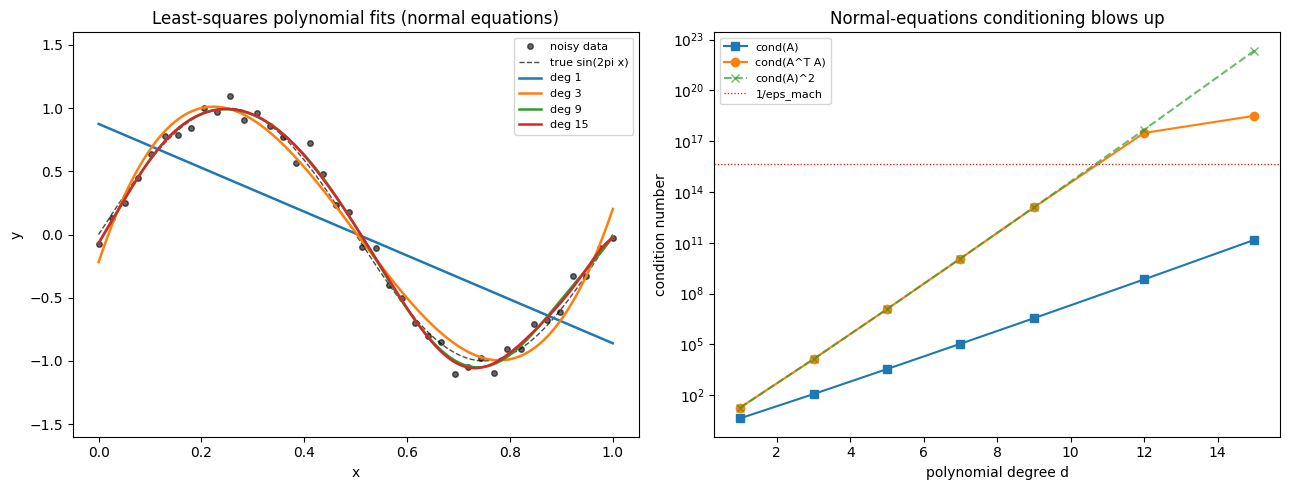

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
xx = np.linspace(0, 1, 400)
ax[0].plot(x, y, "ko", ms=4, alpha=0.6, label="noisy data")
ax[0].plot(xx, g(xx), "k--", lw=1, alpha=0.7, label="true sin(2pi x)")
for d in [1, 3, 9, 15]:
    yy = np.vander(xx, d+1, increasing=True) @ fits[d]
    ax[0].plot(xx, yy, lw=1.8, label=f"deg {d}")
ax[0].set_xlabel("x"); ax[0].set_ylabel("y")
ax[0].set_title("Least-squares polynomial fits (normal equations)")
ax[0].set_ylim(-1.6, 1.6); ax[0].legend(fontsize=8)

ax[1].semilogy(df["degree d"], df["cond(A)"], "s-", label="cond(A)")
ax[1].semilogy(df["degree d"], df["cond(A^T A)"], "o-", label="cond(A^T A)")
ax[1].semilogy(df["degree d"], df["kappa(A)^2"], "x--", alpha=0.7, label="cond(A)^2")
ax[1].axhline(1/np.finfo(float).eps, color="red", ls=":", lw=0.9, label="1/eps_mach")
ax[1].set_xlabel("polynomial degree d"); ax[1].set_ylabel("condition number")
ax[1].set_title("Normal-equations conditioning blows up")
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 4. 결과 해석

1. **잔차 감소**: $d$ 가 커질수록 잔차 노름이 단조 감소. 저차는 과소적합, 고차($d\gtrsim12$)는 잡음까지 따라가는 과대적합.
2. **조건수 제곱**: `ratio` 열에서 $\kappa_2(A^\top A)\approx\kappa_2(A)^2$ 가 수치로 확인된다. $d\approx12\text{–}15$ 에서
   이미 $\kappa(A^\top A)$ 가 $1/\varepsilon_{\text{mach}}\approx10^{16}$ 에 근접 — 계수를 신뢰할 수 없다.
3. **trade-off**: 잔차를 줄이려 차수를 올리면 정규방정식이 수치적으로 무너진다 — 기저나 알고리즘을 바꿔야 한다.

### 결론
> **정규방정식은 가장 단순하지만 $\kappa(A^\top A)=\kappa(A)^2$ 때문에 자릿수 손실이 두 배가 되어,
> 조건이 나쁜 문제(고차 다항식 적합)에서 빠르게 붕괴한다.**

### 다음 문제 연결
- **CE 9.1.2**: 같은 '조건수 제곱'을 정면 측정 — Läuchli 행렬에서 정규방정식 vs **QR 분해** 의 정확도 비교.